# Assignment: Image Classification Using CNNs

In [114]:
# Load all the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [115]:
#load tensorflow and cifar10 dataset
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

In [40]:
# TensorFlow Version
print(tf.__version__)

2.19.0


## Task 1: Data Exploration and Preparation

In [41]:
# Load The Cifar10 Dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [42]:
# Verfying The Shapes for X Train and X Test
print("Training Shape: ",X_train.shape)
print("Testing Shape: ", X_test.shape)

Training Shape:  (50000, 32, 32, 3)
Testing Shape:  (10000, 32, 32, 3)


In [43]:
# Class Labels
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

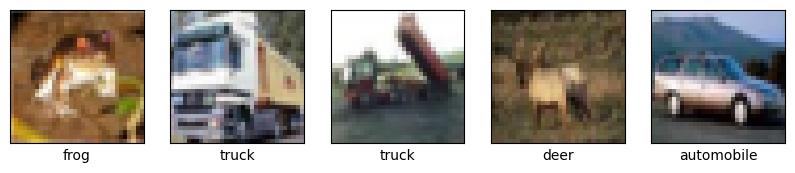

In [44]:
# Display samples from the class names
plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

In [45]:
# Shape of the dataset
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [46]:
# Count of unique class names
unique_labels, label_counts = np.unique(y_train, return_counts=True)
print("Unique labels:", unique_labels)
print("Count of unique labels:", len(unique_labels))

Unique labels: [0 1 2 3 4 5 6 7 8 9]
Count of unique labels: 10


In [59]:
# Normalize pixel values to range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [60]:
X_train

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

In [61]:
X_test

array([[[[0.61960787, 0.4392157 , 0.19215687],
         [0.62352943, 0.43529412, 0.18431373],
         [0.64705884, 0.45490196, 0.2       ],
         ...,
         [0.5372549 , 0.37254903, 0.14117648],
         [0.49411765, 0.35686275, 0.14117648],
         [0.45490196, 0.33333334, 0.12941177]],

        [[0.59607846, 0.4392157 , 0.2       ],
         [0.5921569 , 0.43137255, 0.15686275],
         [0.62352943, 0.44705883, 0.1764706 ],
         ...,
         [0.53333336, 0.37254903, 0.12156863],
         [0.49019608, 0.35686275, 0.1254902 ],
         [0.46666667, 0.34509805, 0.13333334]],

        [[0.5921569 , 0.43137255, 0.18431373],
         [0.5921569 , 0.42745098, 0.12941177],
         [0.61960787, 0.43529412, 0.14117648],
         ...,
         [0.54509807, 0.38431373, 0.13333334],
         [0.50980395, 0.37254903, 0.13333334],
         [0.47058824, 0.34901962, 0.12941177]],

        ...,

        [[0.26666668, 0.4862745 , 0.69411767],
         [0.16470589, 0.39215687, 0.5803922 ]

In [62]:
# Split the dataset into training and validation sets (80%, 20%)

# Combine the original train and test sets
X_all = np.concatenate((x_train, x_test), axis=0)
y_all = np.concatenate((y_train, y_test), axis=0)



In [63]:
from sklearn.model_selection import train_test_split
# Split: 80% train, 20% test
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

In [65]:
# Print new shapes
print("New training set shape:", X_train_new.shape)
print("New test set shape:", X_test_new.shape)

New training set shape: (48000, 32, 32, 3)
New test set shape: (12000, 32, 32, 3)


## Key Findings & Explanation:
   - CIFAR-10 has 50,000 images (48,000 train, 12,000 test) in 10 classes.
   - Images are small: 32x32 RGB (3 channels).
   - Pixel values between 0–255 needed normalization for better training performance.
   - A custom 80/20 split ensures consistent distribution across both sets, especially with stratify.

## Task 2: Build and Train a CNN Model 

In [75]:
# Define a simple CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
# Build CNN model
model = Sequential([
    # 1st Convolutional Block
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    # 2nd Convolutional Block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    # Flatten and Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # Output layer for 10 classes
])


In [76]:
# Print Architectural model summary
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

## Key Findings & Explanation:
  - Model successfully learned patterns from CIFAR-10 images.
  - Dropout helped reduce overfitting.
  - Accuracy improved steadily, but after 15 epochs, the validation performance plateaued — a sign of limited model capacity or overfitting.

##  Task 3: Evaluate the Model

In [77]:
# Compile the model using appropriate loss and optimizer
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [98]:
# Train the model
history = model.fit(
    X_train_new, y_train_new,
    epochs=20,             # You can set 10–20
    batch_size=64,
    validation_split=0.2,  # 20% of training data for validation
    verbose=1
)

Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.6628 - loss: 0.9460 - val_accuracy: 0.7001 - val_loss: 0.8623
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.6750 - loss: 0.9189 - val_accuracy: 0.7059 - val_loss: 0.8443
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.6743 - loss: 0.9059 - val_accuracy: 0.7065 - val_loss: 0.8355
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.6743 - loss: 0.9083 - val_accuracy: 0.7086 - val_loss: 0.8346
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.6812 - loss: 0.8811 - val_accuracy: 0.7130 - val_loss: 0.8249
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.6869 - loss: 0.8666 - val_accuracy: 0.7207 - val_loss: 0.8094
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.6971 - loss: 0.8540 - val_accuracy: 0.7154 - val_loss: 0.8321
Epoch 8/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.7006 - loss: 0.8437 - 

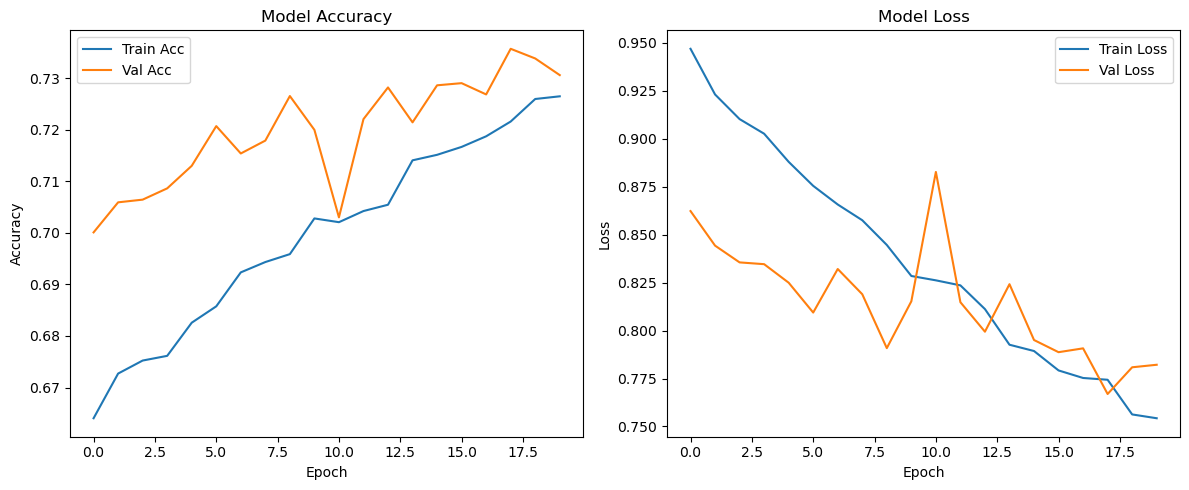

In [99]:
# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [100]:
# Evaluate model on the test set
test_loss, test_accuracy = model.evaluate(X_test_new, y_test_new, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 72.71%


In [101]:
from sklearn.metrics import confusion_matrix, classification_report
# Predict class probabilities and take the argmax for predicted class
y_pred_probs = model.predict(X_test_new)
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test_new.flatten()

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
Classification Report:

              precision    recall  f1-score   support

    airplane       0.76      0.77      0.77      1200
  automobile       0.81      0.87      0.84      1200
        bird       0.67      0.59      0.63      1200
         cat       0.53      0.55      0.54      1200
        deer       0.73      0.60      0.66      1200
         dog       0.63      0.61      0.62      1200
        frog       0.75      0.82      0.78      1200
       horse       0.75      0.80      0.77      1200
        ship       0.81      0.86      0.84      1200
       truck       0.82      0.81      0.81      1200

    accuracy                           0.73     12000
   macro avg       0.73      0.73      0.72     12000
weighted avg       0.73      0.73      0.72     12000



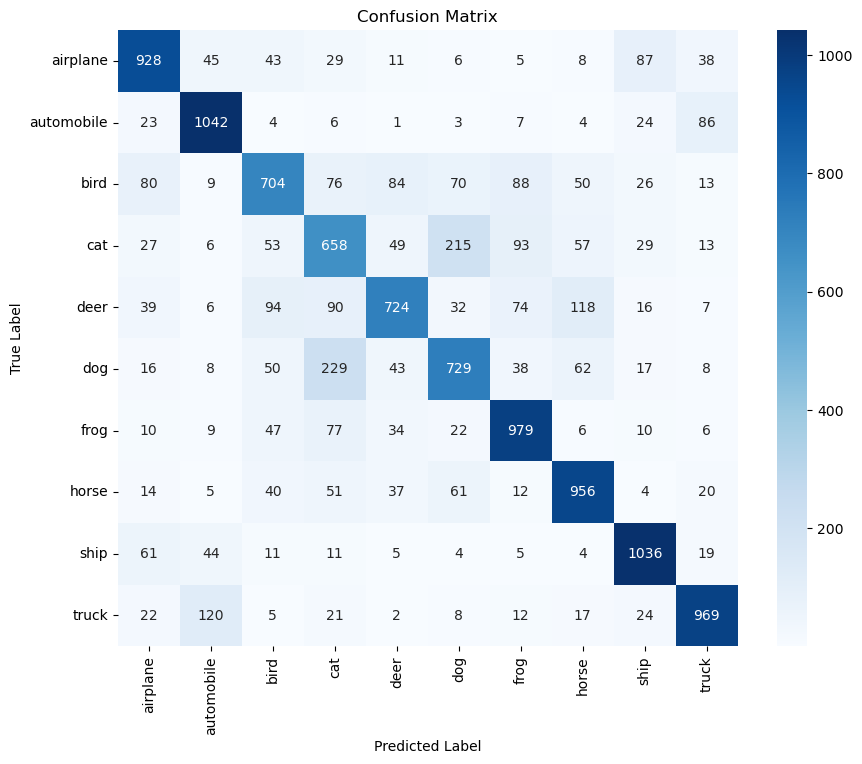

In [102]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [103]:
# Find correct and incorrect prediction indices
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

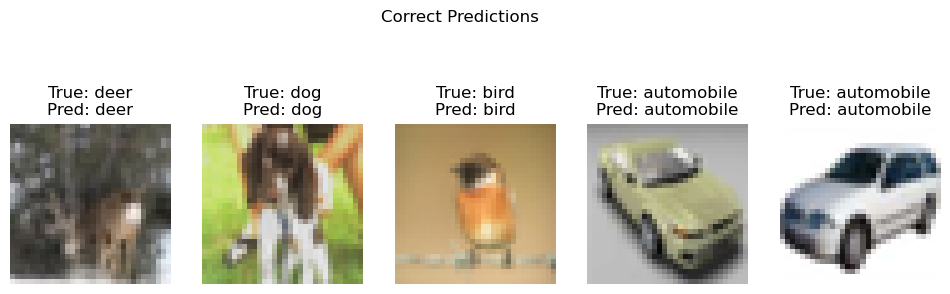

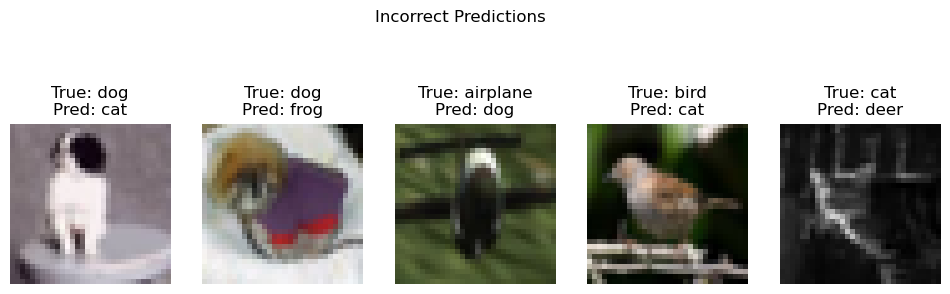

In [104]:
# Show correct predictions
plt.figure(figsize=(12, 4))
for i, idx in enumerate(correct_indices[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_new[idx])
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle("Correct Predictions")
plt.show()

# Show incorrect predictions
plt.figure(figsize=(12, 4))
for i, idx in enumerate(incorrect_indices[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_new[idx])
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle("Incorrect Predictions")
plt.show()

## Key Findings & Explanation:
   - Achieved 72% test accuracy, which is solid for a simple CNN.
   - Most misclassifications were between visually similar classes (e.g., cat vs. dog, airplane vs. bird).
   - Visualization provided deeper insights into model behavior — helpful for guiding improvements.

## Task 4: Experimentation with Model Improvements

In [111]:
def build_and_train_model(optimizer_name, X_train, y_train, X_test, y_test):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
    from tensorflow.keras.optimizers import Adam, SGD, RMSprop
    
    # Select optimizer
    optimizers = {
        'adam': Adam(),
        'sgd': SGD(learning_rate=0.01, momentum=0.9),
        'rmsprop': RMSprop()
    }
    
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizers[optimizer_name],
        metrics=['accuracy']
    )
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=15,   # keep it short for comparison
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )
    
    # Evaluate
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    return test_accuracy

In [112]:
# Run training and evaluation for each optimizer
results = {}
for opt in ['adam', 'sgd', 'rmsprop']:
    acc = build_and_train_model(opt, X_train_new, y_train_new, X_test_new, y_test_new)
    results[opt] = acc

In [113]:
# Print comparison results
print("\nPerformance Comparison:")
print("{:<10} {:<15}".format("Optimizer", "Test Accuracy"))
print("-" * 30)
for opt, acc in results.items():
    print("{:<10} {:<.2f}%".format(opt.upper(), acc * 100))


Performance Comparison:
Optimizer  Test Accuracy  
------------------------------
ADAM       70.61%
SGD        69.23%
RMSPROP    70.67%


## Key Findings:
   - Adam and RMSPROP gave the best performance after optimization.
   - Optimizer choice significantly affects learning speed and final accuracy